In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import colormaps as cm

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FuncAnimation, FFMpegWriter

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import HTML

In [2]:
_scratch = "/pscratch/sd/n/nagarwal"
_prototype = "ocn-only"
_expt = "R5"
_subexpt = "T1M"

In [3]:
_expt_dir = os.path.join(_scratch, _prototype, _expt)
if _subexpt:
    inference_dir = os.path.join(_expt_dir, f"inference_{_subexpt}", "validation")
else:
    inference_dir = os.path.join(_expt_dir, f"inference_{_subexpt}", "validation")

predictions = xr.open_zarr(f"{inference_dir}/graphufs.4320h.zarr")
targets = xr.open_zarr(f"{inference_dir}/replay.4320h.zarr")

In [4]:
predictions

<xarray.Dataset> Size: 2GB
Dimensions:    (lead_time: 180, time: 1, lat: 192, lon: 384, z_l: 7)
Coordinates:
  * lat        (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lead_time  (lead_time) timedelta64[ns] 1kB 1 days 2 days ... 180 days
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time       (time) datetime64[ns] 8B 2022-01-01
  * z_l        (z_l) float64 56B 0.5154 11.06 47.21 93.67 152.1 271.2 417.7
Data variables:
    SSH        (lead_time, time, lat, lon) float32 53MB dask.array<chunksize=(45, 1, 48, 96), meta=np.ndarray>
    so         (lead_time, time, z_l, lat, lon) float32 372MB dask.array<chunksize=(45, 1, 2, 48, 96), meta=np.ndarray>
    temp       (lead_time, time, z_l, lat, lon) float32 372MB dask.array<chunksize=(45, 1, 2, 48, 96), meta=np.ndarray>
    uo         (lead_time, time, z_l, lat, lon) float32 372MB dask.array<chunksize=(45, 1, 2, 48, 96), meta=np.ndarray>
    vo         (lead_time, time, z_l, lat, lon) float32 372MB dask.array<chunksize=(45, 1, 2, 48, 96), meta=np.ndarray>

In [6]:
# Open the atm replay zarr-store
atm = xr.open_zarr(
    "gs://noaa-ufs-gefsv13replay/ufs-hr1/0.25-degree-subsampled/03h-freq/zarr/fv3.zarr",
    storage_options={"token": "anon"},
)
atm

<xarray.Dataset> Size: 60TB
Dimensions:        (time: 87020, grid_yt: 192, grid_xt: 384, pfull: 127)
Coordinates:
    cftime         (time) object 696kB dask.array<chunksize=(21755,), meta=np.ndarray>
    ftime          (time) timedelta64[ns] 696kB dask.array<chunksize=(21755,), meta=np.ndarray>
  * grid_xt        (grid_xt) float64 3kB 0.0 0.9375 1.875 ... 357.2 358.1 359.1
  * grid_yt        (grid_yt) float64 2kB 89.82 88.89 87.95 ... -88.18 -89.12
  * pfull          (pfull) float32 508B 0.01278 0.02033 0.03177 ... 996.2 998.8
  * time           (time) datetime64[ns] 696kB 1993-12-31T18:00:00 ... 2023-1...
Data variables: (12/183)
    acond          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    albdo_ave      (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alnsf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alnwf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alvsf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    alvwf          (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    ...             ...
    xtts           (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xu             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xv             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xz             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    xzts           (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    zc             (time, grid_yt, grid_xt) float32 26GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
Attributes:
    abstract:         The NOAA Unified Forecast System (UFS) / Global Ensembl...
    acknowledgement:  To provide appropriate attribution under this license, ...
    description:      This zarr store is a subset of the original GEFSv13 UFS...
    license:          The Global Ensemble Forecast System version 13 (GEFSv13...

In [7]:
# Open the existing ocean zarr-store
ocn = xr.open_zarr(
    "gs://noaa-ufs-gefsv13replay/ufs-hr1/0.25-degree-subsampled/06h-freq/zarr/mom6.zarr",
    storage_options={"token": "anon"},
)
ocn

<xarray.Dataset> Size: 5TB
Dimensions:       (time: 43826, lat: 192, lon: 384, zl: 75, z_l: 75)
Coordinates:
    cftime        (time) object 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
    ftime         (time) timedelta64[ns] 351kB dask.array<chunksize=(21913,), meta=np.ndarray>
  * lat           (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lon           (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * time          (time) datetime64[ns] 351kB 1993-12-31T18:00:00 ... 2023-12-31
  * z_l           (z_l) float64 600B 0.5154 1.571 2.687 ... 5.698e+03 5.902e+03
  * zl            (zl) float64 600B 1.0 3.0 5.0 ... 3.591e+03 5.111e+03
Data variables: (12/20)
    Heat_PmE      (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    LW            (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    LwLatSens     (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    SSH           (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    SW            (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    evap          (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    ...            ...
    so            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    taux          (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    tauy          (time, lat, lon) float32 13GB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    temp          (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    uo            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
    vo            (time, z_l, lat, lon) float32 969GB dask.array<chunksize=(1, 75, 192, 384), meta=np.ndarray>
Attributes:
    abstract:         The NOAA Unified Forecast System (UFS) / Global Ensembl...
    acknowledgement:  To provide appropriate attribution under this license, ...
    description:      This zarr store is a subset of the original GEFSv13 UFS...
    license:          The Global Ensemble Forecast System version 13 (GEFSv13...

In [8]:
climatology = ocn["temp"].isel(z_l=0).sel(time=slice("1993-12-31", "2019-12-31")).groupby("time.month").mean("time").load()

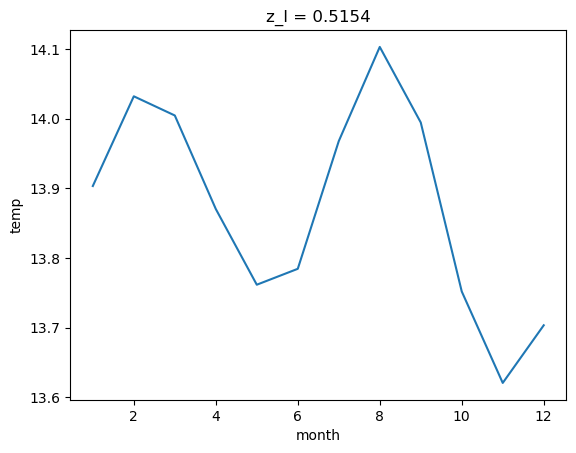

In [9]:
climatology.mean(("lat","lon")).plot()
plt.show()

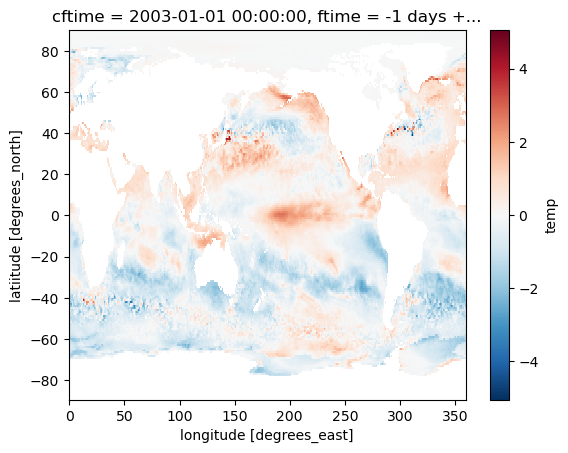

In [11]:
anomaly = ocn["temp"].unify_chunks().isel(z_l=0).sel(time=slice("2003-01-01", "2003-02-28")).groupby("time.month") - climatology
anomaly.isel(time=0).plot()
plt.show()

In [ ]:
%matplotlib notebook

# data to plot
variable = "temp"
units = "degC"
es_comp = "ocn"
vcoord = "z_l"
ilevel = 0
itime = 0

# plotting related 
model = "ocn_only_24h_T1M"
truth = "Replay"
plot_anomaly = True
lat_max_from_equator_for_anim = 10
nlevels = 100
save_plot = False

# initial face of the globe
central_lat_init = 10
central_lon_init = -50

# colorbar related
vmin_cbar = -5
vmax_cbar = 5
cmap = cm.GHRSST_anomaly #SSHA: cm.BlueYellowRed  # SSH:cm.balance, SST_anomaly:cm.GHRSST_anomaly
masked_array = True # true for masked arrays like those for ocn, land, ice

# 3D variable
if vcoord in predictions[variable].coords:
    target = targets[variable].isel({"time":itime, vcoord:ilevel,"lead_time":slice(0,5)})
    prediction = predictions[variable].isel({"time":itime, vcoord:ilevel, "lead_time":slice(0,5)})
    
    # compute and apply mask if ocean
    if vcoord == "z_l":
        mask = xr.where(targets.so.isel({"time":itime, vcoord:ilevel,})==0, 0, 1)
        #mask = 1 - ocn.landsea_mask.sel(z_l=prediction.z_l.values, method="nearest")
        target = target.where(mask)
        prediction = prediction.where(mask)
        masked_array = True
        
# 2D variable
else:
    target = targets[variable].isel(time=itime, lead_time=slice(0,4*30))
    prediction = predictions[variable].isel(time=itime, lead_time=slice(0,4*30))
    
    # compute and apply mask if ssh (the only 2D ocn variable)
    if variable.lower() == "ssh":
        mask = 1 - np.isnan(ocn.SSH.isel(time=0))
        target = target * mask
        prediction = prediction * mask
        masked_array = True

# Remove the mean for anomaly
if plot_anomaly:
    #if es_comp == "ocn":
    #    if vcoord in prediction.coords:
    #        mean_var = ocn[variable].isel({vcoord:ilevel}).mean(dim=("time",)).compute()
    #    else:
    #        mean_var = ocn[variable].mean(dim=("time",)).compute()
    #else:
    #    if vcoord in prediction.coords:
    #        mean_var = atm[variable].isel({vcoord:ilevel}).mean(dim=("time",)).compute()
    #    else:
    #        mean_var = atm[variable].mean(dim=("time",)).compute()
    
    # remove the mean
    #if es_comp == "ocn":
    #    if vcoord in prediction.coords:
    #        climatology = ocn[variable].isel({vcoord:ilevel}).sel(time=slice("1993-12-31T18", "2019-12-31T18")).groupby("time.month").mean("time").compute()
    #    else:
    #        climatology = ocn[variable].sel(time=slice("1993-12-31T18", "2019-12-31T18")).groupby("time.month").mean("time").compute()
    #    prediction = prediction.groupby("lead_time.month") - climatology
    #    target = target.groupby("lead_time.month") - climatology
    # 
    # else: # any other component
    #    if vcoord in prediction.coords:
    #        climatology = ocn[variable].isel({vcoord:ilevel}).sel(time=slice("1993-12-31T18", "2019-12-31T18")).mean("time").compute()
    #    else:
    #        climatology = ocn[variable].sel(time=slice("1993-12-31T18", "2019-12-31T18")).mean("time").compute()
    if climatology.any():
        print("Using the precomputed climatology for computing anomalies; make sure that it belongs to the correct variable")
        
        forecast_time = prediction["time"] + prediction["lead_time"]
        prediction.coords["forecast_time"] = (("lead_time"), forecast_time.values)
        target.coords["forecast_time"] = (("lead_time"), forecast_time.values)
        
        prediction = prediction.groupby("forecast_time.month") - climatology
        target = target.groupby("forecast_time.month") - climatology
    
# meta data
lons = prediction["lon"]
lats = prediction["lat"]
times = prediction["lead_time"]
lon2d, lat2d = np.meshgrid(lons, lats)

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(14, 7.5),
                        subplot_kw={'projection': ccrs.Orthographic(central_longitude=central_lon_init, central_latitude=central_lat_init)})

# Create a shared colorbar axis
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.03])  # [left, bottom, width, height]

# Create a placeholder for colorbar (will update in first frame)
first_cf = None

# colorbar related
norm = Normalize(vmin=vmin_cbar, vmax=vmax_cbar)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Required for colorbar to work

def update(frame):
    fig.subplots_adjust(wspace=0.05, hspace=0.05)

    for ax in axs:
        ax.clear()

    # Compute new central longitude and latitude
    central_lon = (central_lon_init - frame * 2) % 360  # Rotate longitude faster
    central_lat = central_lat_init #+ lat_max_from_equator_for_anim * np.sin(np.radians(frame * 5))  # Oscillate latitude between, say, -10 and +10 degrees

    # Left Globe -- Target
    ax_left = axs[0]
    proj_left = ccrs.Orthographic(central_longitude=central_lon, central_latitude=central_lat)
    ax_left.projection = proj_left
    ax_left.set_global()
    ax_left.coastlines()
    #ax_left.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax_left.add_feature(cfeature.LAND, facecolor='black',)
    ax_left.add_feature(cfeature.RIVERS, linewidth=0.3,)
    cf_left = ax_left.contourf(lon2d, lat2d, target.isel(lead_time=frame).squeeze(), nlevels,
                               transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin_cbar,
                               vmax=vmax_cbar, extend='both')

    # Right Globe -- Prediction
    ax_right = axs[1]
    proj_right = ccrs.Orthographic(central_longitude=central_lon, central_latitude=central_lat)
    ax_right.projection = proj_right
    ax_right.set_global()
    ax_right.coastlines()
    #ax_right.add_feature(cfeature.BORDERS, linewidth=0.5,)
    ax_right.add_feature(cfeature.LAND, facecolor='black',)
    ax_right.add_feature(cfeature.RIVERS, linewidth=0.3,)
    cf_right = ax_right.contourf(lon2d, lat2d, prediction.isel(lead_time=frame).squeeze(), nlevels,
                                 transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin_cbar, 
                                 vmax=vmax_cbar, extend='both')
    
    global first_cf
    if first_cf is None:
        first_cf = cf_left
        # Create a colorbar only once
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",)
        cbar.set_label(f"{units}")
        cbar.ax.tick_params(labelsize=10)
        
    axs[0].set_title(truth, fontsize=12)
    axs[1].set_title(model, fontsize=12)

    leadtime = pd.to_timedelta(times[frame].values, unit="D")
    print(f"lead time = {leadtime}")
    title = f"{variable} anomaly, lead time = {leadtime}"
    if vcoord in predictions[variable].coords:
        title += f", {vcoord} = {prediction[vcoord][0].values:.2f}m" # remove m if using atm
    plt.suptitle(title)

    return []

# Animate
ani = FuncAnimation(fig, update, frames=len(times), interval=500, blit=False)

# if 3D
if vcoord in predictions[variable].coords:
    if plot_anomaly:
        fname = f"{variable}_anomaly_predictions_targets_{vcoord}-{prediction[vcoord][0].values:.2f}m_{model}.mp4"
    else:
        fname = f"{variable}_predictions_targets_{vcoord}-{prediction[vcoord][0].values:.2f}m_{model}.mp4"
# if 2D
else:
    if plot_anomaly:
        fname = f"{variable}_anomaly_predictions_targets_{model}_{_expt}.mp4"
    else:
        fname = f"{variable}_predictions_targets_{model}_{_expt}.mp4"

if save_plot:
    ani.save(f"figures/{fname}", writer='ffmpeg', fps=8, dpi=200)
else:
    Display animation
    HTML(ani.to_jshtml())

## Make videos using the PlateCarree projection, not orthographic

In [26]:
%matplotlib notebook

# data to plot
variable = "temp"
units = "degC"
es_comp = "ocn"
vcoord = "z_l"
ilevel = 0
itime = 0

# plotting related 
model = "ocn_only_24h_T1M"
truth = "Replay"
plot_anomaly = True
lat_max_from_equator_for_anim = 10
nlevels = 100
save_plot = False

# colorbar related
vmin_cbar = -5
vmax_cbar = 5
cmap = cm.GHRSST_anomaly #SSHA: cm.BlueYellowRed  # SSH:cm.balance, SST_anomaly:cm.GHRSST_anomaly
masked_array = True # true for masked arrays like those for ocn, land, ice

# 3D variable
if vcoord in predictions[variable].coords:
    target = targets[variable].isel({"time":itime, vcoord:ilevel,"lead_time":slice(0,5)})
    prediction = predictions[variable].isel({"time":itime, vcoord:ilevel, "lead_time":slice(0,5)})
    
    # compute and apply mask if ocean
    if vcoord == "z_l":
        mask = xr.where(targets.so.isel({"time":itime, vcoord:ilevel,})==0, 0, 1)
        #mask = 1 - ocn.landsea_mask.sel(z_l=prediction.z_l.values, method="nearest")
        target = target.where(mask)
        prediction = prediction.where(mask)
        masked_array = True
        
# 2D variable
else:
    target = targets[variable].isel(time=itime, lead_time=slice(0,4*30))
    prediction = predictions[variable].isel(time=itime, lead_time=slice(0,4*30))
    
    # compute and apply mask if ssh (the only 2D ocn variable)
    if variable.lower() == "ssh":
        mask = 1 - np.isnan(ocn.SSH.isel(time=0))
        target = target * mask
        prediction = prediction * mask
        masked_array = True

# Remove the mean for anomaly
if plot_anomaly:
    #if es_comp == "ocn":
    #    if vcoord in prediction.coords:
    #        mean_var = ocn[variable].isel({vcoord:ilevel}).mean(dim=("time",)).compute()
    #    else:
    #        mean_var = ocn[variable].mean(dim=("time",)).compute()
    #else:
    #    if vcoord in prediction.coords:
    #        mean_var = atm[variable].isel({vcoord:ilevel}).mean(dim=("time",)).compute()
    #    else:
    #        mean_var = atm[variable].mean(dim=("time",)).compute()
    
    # remove the mean
    #if es_comp == "ocn":
    #    if vcoord in prediction.coords:
    #        climatology = ocn[variable].isel({vcoord:ilevel}).sel(time=slice("1993-12-31T18", "2019-12-31T18")).groupby("time.month").mean("time").compute()
    #    else:
    #        climatology = ocn[variable].sel(time=slice("1993-12-31T18", "2019-12-31T18")).groupby("time.month").mean("time").compute()
    #    prediction = prediction.groupby("lead_time.month") - climatology
    #    target = target.groupby("lead_time.month") - climatology
    # 
    # else: # any other component
    #    if vcoord in prediction.coords:
    #        climatology = ocn[variable].isel({vcoord:ilevel}).sel(time=slice("1993-12-31T18", "2019-12-31T18")).mean("time").compute()
    #    else:
    #        climatology = ocn[variable].sel(time=slice("1993-12-31T18", "2019-12-31T18")).mean("time").compute()
    if climatology.any():
        print("Using the precomputed climatology for computing anomalies; make sure that it belongs to the correct variable")
        
        forecast_time = prediction["time"] + prediction["lead_time"]
        prediction.coords["forecast_time"] = (("lead_time"), forecast_time.values)
        target.coords["forecast_time"] = (("lead_time"), forecast_time.values)
        
        prediction = prediction.groupby("forecast_time.month") - climatology
        target = target.groupby("forecast_time.month") - climatology
    
# meta data
lons = prediction["lon"]
lats = prediction["lat"]
times = prediction["lead_time"]
lon2d, lat2d = np.meshgrid(lons, lats)

# Create figure
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5),
                        subplot_kw={'projection': ccrs.Orthographic(central_longitude=central_lon_init, central_latitude=central_lat_init)})

# Create a shared colorbar axis
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.03])  # [left, bottom, width, height]

# Create a placeholder for colorbar (will update in first frame)
first_cf = None

# colorbar related
norm = Normalize(vmin=vmin_cbar, vmax=vmax_cbar)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Required for colorbar to work

def update(frame):
    fig.subplots_adjust(wspace=0.05, hspace=0.05)

    for ax in axs:
        ax.clear()

    # Left panel -- Target
    ax_left = axs[0]
    proj_left = ccrs.PlateCarree()
    ax_left.projection = proj_left
    ax_left.set_global()
    ax_left.coastlines()
    #ax_left.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax_left.add_feature(cfeature.LAND, facecolor='black',)
    ax_left.add_feature(cfeature.RIVERS, linewidth=0.3,)
    cf_left = ax_left.contourf(lon2d, lat2d, target.isel(lead_time=frame).squeeze(), nlevels,
                               transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin_cbar,
                               vmax=vmax_cbar, extend='both')

    # Right Panel -- Prediction
    ax_right = axs[1]
    proj_right = ccrs.PlateCarree()
    ax_right.projection = proj_right
    ax_right.set_global()
    ax_right.coastlines()
    #ax_right.add_feature(cfeature.BORDERS, linewidth=0.5,)
    ax_right.add_feature(cfeature.LAND, facecolor='black',)
    ax_right.add_feature(cfeature.RIVERS, linewidth=0.3,)
    cf_right = ax_right.contourf(lon2d, lat2d, prediction.isel(lead_time=frame).squeeze(), nlevels,
                                 transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin_cbar, 
                                 vmax=vmax_cbar, extend='both')
    
    global first_cf
    if first_cf is None:
        first_cf = cf_left
        # Create a colorbar only once
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",)
        cbar.set_label(f"{units}")
        cbar.ax.tick_params(labelsize=10)
        
    axs[0].set_title(truth, fontsize=12)
    axs[1].set_title(model, fontsize=12)

    leadtime = pd.to_timedelta(times[frame].values, unit="D")
    print(f"lead time = {leadtime}")
    title = f"{variable} anomaly, lead time = {leadtime}"
    if vcoord in predictions[variable].coords:
        title += f", {vcoord} = {prediction[vcoord][0].values:.2f}m" # remove m if using atm
    plt.suptitle(title)

    return []

# Animate
ani = FuncAnimation(fig, update, frames=len(times), interval=500, blit=False)

# if 3D
if vcoord in predictions[variable].coords:
    if plot_anomaly:
        fname = f"{variable}_anomaly_predictions_targets_{vcoord}-{prediction[vcoord][0].values:.2f}m_{model}.mp4"
    else:
        fname = f"{variable}_predictions_targets_{vcoord}-{prediction[vcoord][0].values:.2f}m_{model}.mp4"
# if 2D
else:
    if plot_anomaly:
        fname = f"{variable}_anomaly_predictions_targets_{model}_{_expt}.mp4"
    else:
        fname = f"{variable}_predictions_targets_{model}_{_expt}.mp4"

if save_plot:
    ani.save(f"figures/{fname}", writer='ffmpeg', fps=8, dpi=200)
else:
    # Display animation
    HTML(ani.to_jshtml())

Using the precomputed climatology for computing anomalies; make sure that it belongs to the correct variable


<IPython.core.display.Javascript object>

lead time = 1 days 00:00:00
lead time = 1 days 00:00:00
lead time = 2 days 00:00:00
lead time = 3 days 00:00:00
lead time = 4 days 00:00:00
lead time = 5 days 00:00:00
